<a href="https://colab.research.google.com/github/Kryptera-K/PLTR-Stochastic-Bull-Power-Hybrid-Oscillator-SBHO-Strategy/blob/main/PLTR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install vectorbt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.7/527.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 24.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import vectorbt as vbt

# -------------------------
# Download Data
# -------------------------

symbol = "PLTR"
start_date = "2000-01-01"
end_date = "2026-01-01"
interval = "1d"

df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)
df.to_csv("PLTR_clean.csv", index=False)
df

/tmp/ipython-input-2175998361.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2020-09-30,9.500000,11.410000,9.110000,10.000000,338584400
2020-10-01,9.460000,10.100000,9.230000,9.690000,124297600
2020-10-02,9.200000,9.280000,8.940000,9.060000,55018300
2020-10-05,9.030000,9.490000,8.920000,9.430000,36316900
2020-10-06,9.900000,10.180000,8.900000,9.040000,90864000
...,...,...,...,...,...
2025-10-20,181.589996,183.089996,177.440002,179.490005,31975800
2025-10-21,181.509995,182.389008,178.649994,182.059998,27528100
2025-10-22,175.490005,182.210007,169.419998,181.929993,58263100


In [ ]:
# -------------------------
# Necessary Parameters
# -------------------------

BULL_EMA_PERIOD = 13
BULL_LEVEL = 0
CCI_LEVEL = 0
CCI_PERIOD = 14
CCI_SHIFT = 5
CCI_SHIFT_2 = 10
STOCHASTIC_D_PERIOD = 3
STOCHASTIC_K_PERIOD = 14
STOCHASTIC_OVERBOUGHT = 80
STOCHASTIC_OVERSOLD = 20

# -------------------------
# Indicator Functions
# -------------------------

def slow_d_falling(df):
    df = calculate_stochastic(df)
    return df['Slow_%D'].diff() < 0


def calculate_stochastic(df, k_period=STOCHASTIC_K_PERIOD, d_period=STOCHASTIC_D_PERIOD):
    """Calculate Fast %K and Slow %D"""
    low_min = df['Low'].rolling(window=k_period).min()
    high_max = df['High'].rolling(window=k_period).max()

    df['Fast_%K'] = 100 * (df['Close'] - low_min) / (high_max - low_min)
    df['Slow_%D'] = df['Fast_%K'].rolling(window=d_period).mean()
    return df


def bull_power_change_up(df, EMA_PERIOD=BULL_EMA_PERIOD):
    df = calculate_bull_power(df, EMA_PERIOD)
    return df['Bull_Power'] > df['Bull_Power'].shift(1)


def calculate_bull_power(df, EMA_PERIOD=BULL_EMA_PERIOD):
    """
    Calculate Bull Power indicator.
    Bull Power = High - EMA(Close)
    """
    df = df.copy()
    df['EMA'] = df['Close'].ewm(span=EMA_PERIOD, adjust=False).mean()
    df['Bull_Power'] = df['High'] - df['EMA']
    return df


def bull_power_is_rising(df, EMA_PERIOD=BULL_EMA_PERIOD):
    df = calculate_bull_power(df, EMA_PERIOD)
    return df['Bull_Power'].diff() > 0


def cci_change_up(df, period=CCI_PERIOD, shifts=CCI_SHIFT, shift_2=CCI_SHIFT_2):
    df['CCI_main'] = calculate_cci(df, period)['CCI']
    return (df['CCI_main'] > df['CCI_main'].shift(shifts)) & \
           (df['CCI_main'].shift(shifts) <= df['CCI_main'].shift(shift_2))


def calculate_cci(df, period=CCI_PERIOD):
    """
    Calculate Commodity Channel Index (CCI).
    """
    df = df.copy()
    # Typical Price
    df['TP'] = (df['High'] + df['Low'] + df['Close']) / 3
    # SMA of TP
    df['SMA_TP'] = df['TP'].rolling(period).mean()
    # Mean Deviation
    df['MeanDev'] = df['TP'].rolling(period).apply(
        lambda x: np.mean(np.abs(x - np.mean(x))), raw=True
    )
    # CCI
    df['CCI'] = (df['TP'] - df['SMA_TP']) / (0.015 * df['MeanDev'])
    return df



# -------------------------
# Entry conditions
# -------------------------

df["Stochastic_Slow_%D_Falling"] = slow_d_falling(df)
df["BullP_Upward"] = bull_power_change_up(df)

# -------------------------
# Exit conditions
# -------------------------

df["BullP_Rising"] = bull_power_is_rising(df)
df["CCI_Change_Up"] = cci_change_up(df)

# -------------------------
# Signals
# -------------------------

entry_conditions = [
    'Stochastic_Slow_%D_Falling',
    'BullP_Upward',
]
exit_conditions = [
    'BullP_Rising',
    'CCI_Change_Up',
]

df['entry_signal'] = df[entry_conditions].all(axis=1)
df['exit_signal']  = df[exit_conditions].all(axis=1)

# -------------------------
# Backtest
# -------------------------


shift_entries = df['entry_signal'].shift(1).astype(bool).fillna(False).to_numpy()
shift_exits = df['exit_signal'].shift(1).astype(bool).fillna(False).to_numpy()

pf = vbt.Portfolio.from_signals(
    close=df['Open'],
    entries=shift_entries,
    exits=shift_exits,
    init_cash=100_000,
    fees=0.001,
    slippage=0.002,
    freq='1d'
)


# -------------------------
# Portfolio Stats / Plot
# -------------------------

print(pf.stats())
pf.plot().show()

Start                               2020-09-30 00:00:00
End                                 2025-10-24 00:00:00
Period                               1274 days 00:00:00
Start Value                                    100000.0
End Value                                4748973.215527
Total Return [%]                            4648.973216
Benchmark Return [%]                        1728.800049
Max Gross Exposure [%]                            100.0
Total Fees Paid                           167515.911121
Max Drawdown [%]                              53.269998
Max Drawdown Duration                 449 days 00:00:00
Total Trades                                         70
Total Closed Trades                                  69
Total Open Trades                                     1
Open Trade PnL                            179392.968604
Win Rate [%]                                  71.014493
Best Trade [%]                               109.723161
Worst Trade [%]                              -21

In [ ]:
# Buy and Hold Performance Metrics
df_holding = df['Open']
pf_holding = vbt.Portfolio.from_holding(df_holding, init_cash=100_000 , freq='D')
print(pf_holding.stats())

Start                         2020-09-30 00:00:00
End                           2025-10-24 00:00:00
Period                         1274 days 00:00:00
Start Value                              100000.0
End Value                          1828800.048828
Total Return [%]                      1728.800049
Benchmark Return [%]                  1728.800049
Max Gross Exposure [%]                      100.0
Total Fees Paid                               0.0
Max Drawdown [%]                        84.876075
Max Drawdown Duration           926 days 00:00:00
Total Trades                                    1
Total Closed Trades                             0
Total Open Trades                               1
Open Trade PnL                     1728800.048828
Win Rate [%]                                  NaN
Best Trade [%]                                NaN
Worst Trade [%]                               NaN
Avg Winning Trade [%]                         NaN
Avg Losing Trade [%]                          NaN


/tmp/ipython-input-926617194.py:14: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


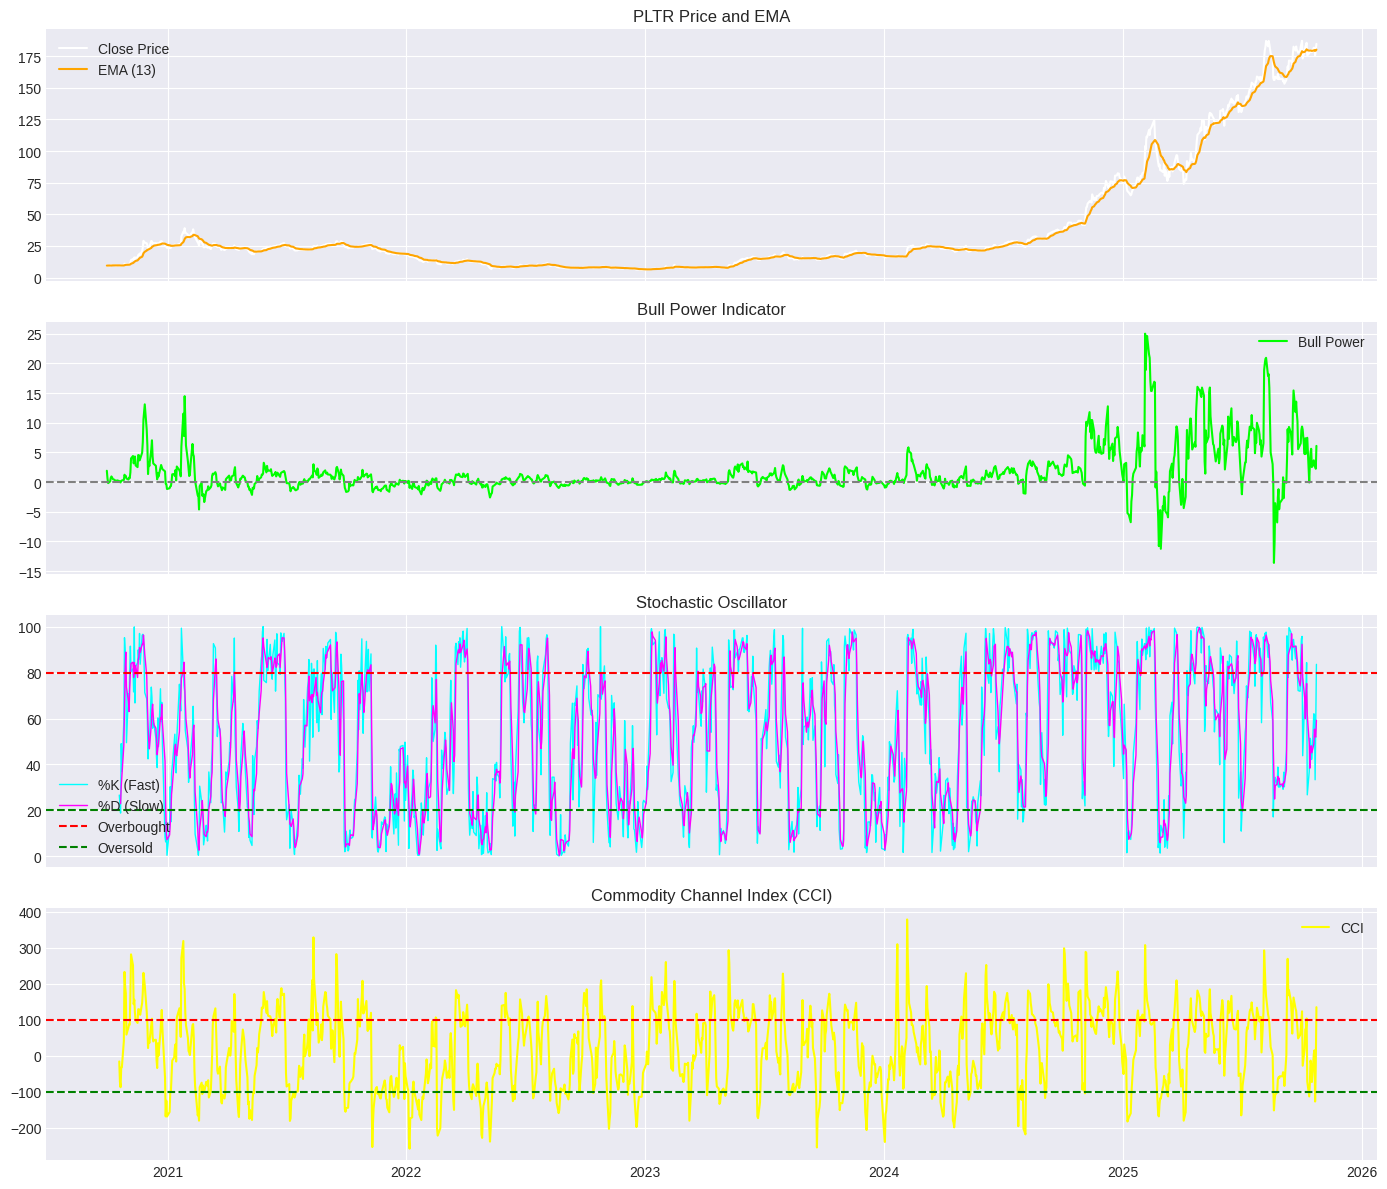

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# -------------------------
# Download Data
# -------------------------
symbol = "PLTR"
start_date = "2000-01-01"
end_date = "2026-01-01"
interval = "1d"

df = yf.download(symbol, start=start_date, end=end_date, interval=interval, multi_level_index=False)
df.dropna(inplace=True)

# -------------------------
# Parameters
# -------------------------
BULL_EMA_PERIOD = 13
CCI_PERIOD = 14
STOCHASTIC_D_PERIOD = 3
STOCHASTIC_K_PERIOD = 14
STOCHASTIC_OVERBOUGHT = 80
STOCHASTIC_OVERSOLD = 20

# -------------------------
# Indicator Calculations
# -------------------------
def calculate_bull_power(df, EMA_PERIOD=BULL_EMA_PERIOD):
    df = df.copy()
    df['EMA'] = df['Close'].ewm(span=EMA_PERIOD, adjust=False).mean()
    df['Bull_Power'] = df['High'] - df['EMA']
    return df

def calculate_stochastic(df, k_period=STOCHASTIC_K_PERIOD, d_period=STOCHASTIC_D_PERIOD):
    df = df.copy()
    low_min = df['Low'].rolling(window=k_period).min()
    high_max = df['High'].rolling(window=k_period).max()
    df['Fast_%K'] = 100 * (df['Close'] - low_min) / (high_max - low_min)
    df['Slow_%D'] = df['Fast_%K'].rolling(window=d_period).mean()
    return df

def calculate_cci(df, period=CCI_PERIOD):
    df = df.copy()
    df['TP'] = (df['High'] + df['Low'] + df['Close']) / 3
    df['SMA_TP'] = df['TP'].rolling(period).mean()
    df['MeanDev'] = df['TP'].rolling(period).apply(lambda x: np.mean(np.abs(x - np.mean(x))), raw=True)
    df['CCI'] = (df['TP'] - df['SMA_TP']) / (0.015 * df['MeanDev'])
    return df

# Apply indicators
df = calculate_bull_power(df)
df = calculate_stochastic(df)
df = calculate_cci(df)

# -------------------------
# Plot All Indicators
# -------------------------
plt.style.use("seaborn-v0_8-darkgrid")
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# --- Price + EMA ---
axes[0].plot(df.index, df['Close'], label='Close Price', color='white')
axes[0].plot(df.index, df['EMA'], label=f'EMA ({BULL_EMA_PERIOD})', color='orange', linewidth=1.5)
axes[0].set_title(f'{symbol} Price and EMA')
axes[0].legend()

# --- Bull Power ---
axes[1].plot(df.index, df['Bull_Power'], label='Bull Power', color='lime')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('Bull Power Indicator')
axes[1].legend()

# --- Stochastic Oscillator ---
axes[2].plot(df.index, df['Fast_%K'], label='%K (Fast)', color='cyan', linewidth=1)
axes[2].plot(df.index, df['Slow_%D'], label='%D (Slow)', color='magenta', linewidth=1)
axes[2].axhline(STOCHASTIC_OVERBOUGHT, color='red', linestyle='--', label='Overbought')
axes[2].axhline(STOCHASTIC_OVERSOLD, color='green', linestyle='--', label='Oversold')
axes[2].set_title('Stochastic Oscillator')
axes[2].legend()

# --- CCI ---
axes[3].plot(df.index, df['CCI'], label='CCI', color='yellow')
axes[3].axhline(100, color='red', linestyle='--')
axes[3].axhline(-100, color='green', linestyle='--')
axes[3].set_title('Commodity Channel Index (CCI)')
axes[3].legend()

plt.tight_layout()
plt.show()
